In [80]:
import pandas as pd
df = pd.read_csv('Loan_default.csv')

In [81]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('whitegrid')

In [82]:
print("Data Shape:")
print(df.shape)
print("\nData Info:")
df.info()

Data Shape:
(148670, 34)

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  object 
 3   Gender                     148670 non-null  object 
 4   approv_in_adv              147762 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148536 non-null  object 
 7   Credit_Worthiness          148670 non-null  object 
 8   open_credit                148670 non-null  object 
 9   business_or_commercial     148670 non-null  object 
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float

In [83]:
df.head()

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


In [84]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
ID                               0
year                             0
loan_limit                    3344
Gender                           0
approv_in_adv                  908
loan_type                        0
loan_purpose                   134
Credit_Worthiness                0
open_credit                      0
business_or_commercial           0
loan_amount                      0
rate_of_interest             36439
Interest_rate_spread         36639
Upfront_charges              39642
term                            41
Neg_ammortization              121
interest_only                    0
lump_sum_payment                 0
property_value               15098
construction_type                0
occupancy_type                   0
Secured_by                       0
total_units                      0
income                        9150
credit_type                      0
Credit_Score                     0
co-applicant_credit_type         0
age                     

In [85]:
numerical_col = df.select_dtypes(include=np.number).columns.tolist()

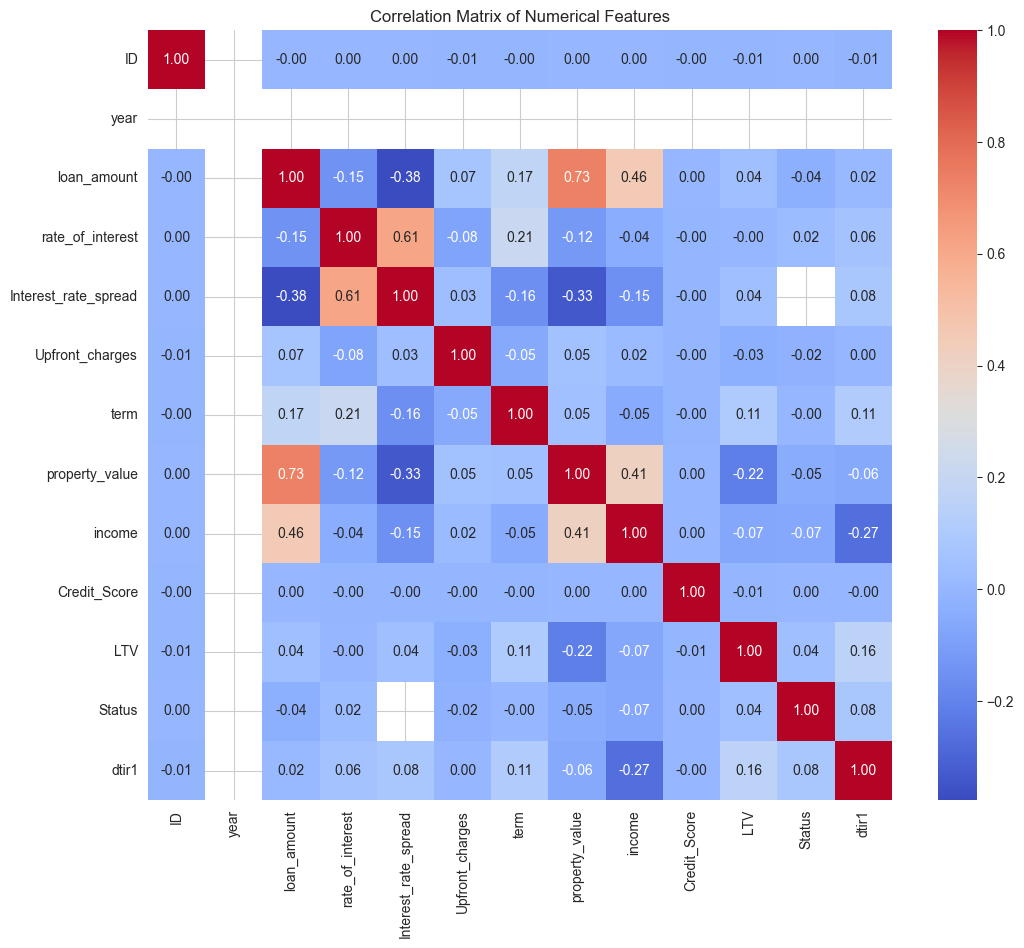

In [86]:
correlation_matrix = df[numerical_col].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [87]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [88]:
df.head()

,id,year,loan_limit,gender,approv_in_adv,loan_type,loan_purpose,credit_worthiness,open_credit,business_or_commercial,...,credit_type,credit_score,co-applicant_credit_type,age,submission_of_application,ltv,region,security_type,status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


In [89]:
df = df.drop(columns=['id', 'year'])

In [90]:
df.columns

Index(['loan_limit', 'gender', 'approv_in_adv', 'loan_type', 'loan_purpose',
       'credit_worthiness', 'open_credit', 'business_or_commercial',
       'loan_amount', 'rate_of_interest', 'interest_rate_spread',
       'upfront_charges', 'term', 'neg_ammortization', 'interest_only',
       'lump_sum_payment', 'property_value', 'construction_type',
       'occupancy_type', 'secured_by', 'total_units', 'income', 'credit_type',
       'credit_score', 'co-applicant_credit_type', 'age',
       'submission_of_application', 'ltv', 'region', 'security_type', 'status',
       'dtir1'],
      dtype='object')

In [91]:
df['has_co_applicant'] = df['co-applicant_credit_type'].notna().astype(int)
df = df.drop(columns=['co-applicant_credit_type'])

In [92]:
df.columns

Index(['loan_limit', 'gender', 'approv_in_adv', 'loan_type', 'loan_purpose',
       'credit_worthiness', 'open_credit', 'business_or_commercial',
       'loan_amount', 'rate_of_interest', 'interest_rate_spread',
       'upfront_charges', 'term', 'neg_ammortization', 'interest_only',
       'lump_sum_payment', 'property_value', 'construction_type',
       'occupancy_type', 'secured_by', 'total_units', 'income', 'credit_type',
       'credit_score', 'age', 'submission_of_application', 'ltv', 'region',
       'security_type', 'status', 'dtir1', 'has_co_applicant'],
      dtype='object')

In [93]:
df.head()

,loan_limit,gender,approv_in_adv,loan_type,loan_purpose,credit_worthiness,open_credit,business_or_commercial,loan_amount,rate_of_interest,...,credit_type,credit_score,age,submission_of_application,ltv,region,security_type,status,dtir1,has_co_applicant
0,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,116500,NaN,...,EXP,758,25-34,to_inst,98.728814,south,direct,1,45.0,1
1,cf,Male,nopre,type2,p1,l1,nopc,b/c,206500,NaN,...,EQUI,552,55-64,to_inst,NaN,North,direct,1,NaN,1
2,cf,Male,pre,type1,p1,l1,nopc,nob/c,406500,4.56,...,EXP,834,35-44,to_inst,80.019685,south,direct,0,46.0,1
3,cf,Male,nopre,type1,p4,l1,nopc,nob/c,456500,4.25,...,EXP,587,45-54,not_inst,69.376900,North,direct,0,42.0,1
4,cf,Joint,pre,type1,p1,l1,nopc,nob/c,696500,4.00,...,CRIF,602,25-34,not_inst,91.886544,North,direct,0,39.0,1


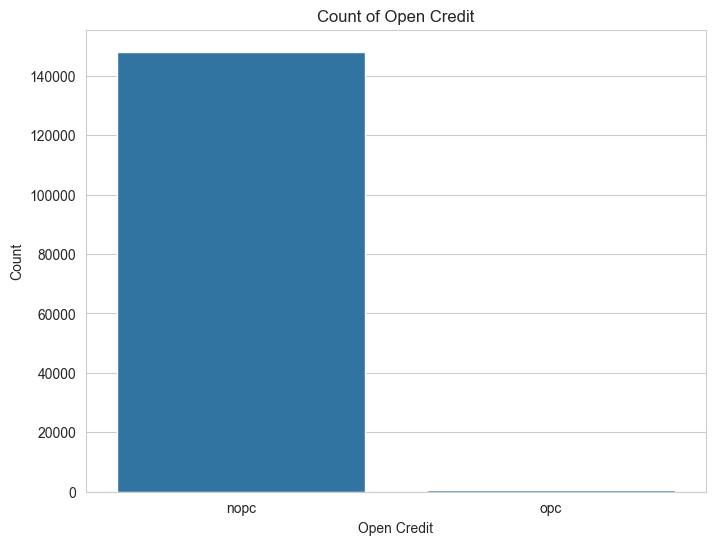

In [94]:
plt.figure(figsize=(8, 6))
sns.countplot(x='open_credit', data=df)
plt.title('Count of Open Credit')
plt.xlabel('Open Credit')
plt.ylabel('Count')
plt.show()

In [95]:
columns_to_check = [
    'open_credit', 'loan_limit', 'approv_in_adv', 'credit_worthiness',
    'business_or_commercial', 'neg_ammortization', 'interest_only',
    'lump_sum_payment', 'construction_type', 'secured_by',
    'submission_of_application', 'security_type'
]

for col in columns_to_check:
    print(f"Value counts for '{col}':")
    print(df[col].value_counts())
    print("\n" + "="*30 + "\n")

Value counts for 'open_credit':
open_credit
nopc    148114
opc        556
Name: count, dtype: int64


Value counts for 'loan_limit':
loan_limit
cf     135348
ncf      9978
Name: count, dtype: int64


Value counts for 'approv_in_adv':
approv_in_adv
nopre    124621
pre       23141
Name: count, dtype: int64


Value counts for 'credit_worthiness':
credit_worthiness
l1    142344
l2      6326
Name: count, dtype: int64


Value counts for 'business_or_commercial':
business_or_commercial
nob/c    127908
b/c       20762
Name: count, dtype: int64


Value counts for 'neg_ammortization':
neg_ammortization
not_neg    133420
neg_amm     15129
Name: count, dtype: int64


Value counts for 'interest_only':
interest_only
not_int     141560
int_only      7110
Name: count, dtype: int64


Value counts for 'lump_sum_payment':
lump_sum_payment
not_lpsm    145286
lpsm          3384
Name: count, dtype: int64


Value counts for 'construction_type':
construction_type
sb    148637
mh        33
Name: count, dtype: 

In [96]:
df.columns

Index(['loan_limit', 'gender', 'approv_in_adv', 'loan_type', 'loan_purpose',
       'credit_worthiness', 'open_credit', 'business_or_commercial',
       'loan_amount', 'rate_of_interest', 'interest_rate_spread',
       'upfront_charges', 'term', 'neg_ammortization', 'interest_only',
       'lump_sum_payment', 'property_value', 'construction_type',
       'occupancy_type', 'secured_by', 'total_units', 'income', 'credit_type',
       'credit_score', 'age', 'submission_of_application', 'ltv', 'region',
       'security_type', 'status', 'dtir1', 'has_co_applicant'],
      dtype='object')

In [97]:
df['status'].value_counts()

status
0    112031
1     36639
Name: count, dtype: int64

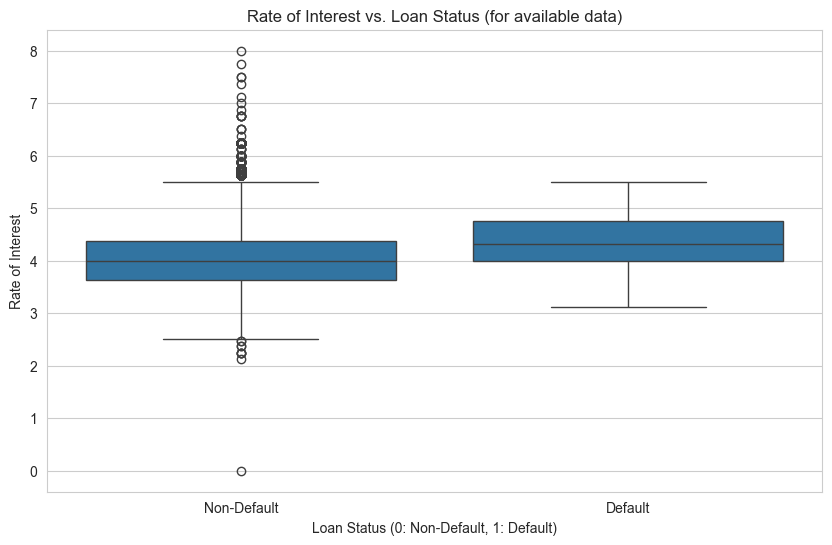

In [98]:
# Creating  a temporary dataframe with only the columns that are needed  for this analysis
temp_df = df[['rate_of_interest', 'status']].copy()


temp_df.dropna(subset=['rate_of_interest'], inplace=True)

# Create the box plot
plt.figure(figsize=(10, 6))
sns.boxplot(x='status', y='rate_of_interest', data=temp_df)
plt.title('Rate of Interest vs. Loan Status (for available data)')
plt.xlabel('Loan Status (0: Non-Default, 1: Default)')
plt.ylabel('Rate of Interest')
plt.xticks([0, 1], ['Non-Default', 'Default'])
plt.show()

In [99]:
# Create indicator column
df['rate_of_interest_was_missing'] = df['rate_of_interest'].isnull().astype(int)

# Calculate median
median_rate_of_interest = df['rate_of_interest'].median()

# Fill missing values safely
df['rate_of_interest'] = df['rate_of_interest'].fillna(median_rate_of_interest)

In [100]:
# Verify the changes
print("Missing values after imputation:")
print(df[['rate_of_interest', 'rate_of_interest_was_missing']].isnull().sum())

print("\nValue counts for 'rate_of_interest_was_missing':")
print(df['rate_of_interest_was_missing'].value_counts())

print("\nFirst 5 rows showing the updated columns:")
display(df[['rate_of_interest', 'rate_of_interest_was_missing']].head())

Missing values after imputation:
rate_of_interest                0
rate_of_interest_was_missing    0
dtype: int64

Value counts for 'rate_of_interest_was_missing':
rate_of_interest_was_missing
0    112231
1     36439
Name: count, dtype: int64

First 5 rows showing the updated columns:


,rate_of_interest,rate_of_interest_was_missing
0,3.99,1
1,3.99,1
2,4.56,0
3,4.25,0
4,4.00,0


In [101]:
print(df.isnull().sum())

loan_limit                       3344
gender                              0
approv_in_adv                     908
loan_type                           0
loan_purpose                      134
credit_worthiness                   0
open_credit                         0
business_or_commercial              0
loan_amount                         0
rate_of_interest                    0
interest_rate_spread            36639
upfront_charges                 39642
term                               41
neg_ammortization                 121
interest_only                       0
lump_sum_payment                    0
property_value                  15098
construction_type                   0
occupancy_type                      0
secured_by                          0
total_units                         0
income                           9150
credit_type                         0
credit_score                        0
age                               200
submission_of_application         200
ltv         

In [102]:
print(df.shape)
print(df.columns)

(148670, 33)
Index(['loan_limit', 'gender', 'approv_in_adv', 'loan_type', 'loan_purpose',
       'credit_worthiness', 'open_credit', 'business_or_commercial',
       'loan_amount', 'rate_of_interest', 'interest_rate_spread',
       'upfront_charges', 'term', 'neg_ammortization', 'interest_only',
       'lump_sum_payment', 'property_value', 'construction_type',
       'occupancy_type', 'secured_by', 'total_units', 'income', 'credit_type',
       'credit_score', 'age', 'submission_of_application', 'ltv', 'region',
       'security_type', 'status', 'dtir1', 'has_co_applicant',
       'rate_of_interest_was_missing'],
      dtype='object')


In [103]:
# Create indicator column for dtir1
df['dtir1_was_missing'] = df['dtir1'].isnull().astype(int)

# Calculate median
median_dtir1 = df['dtir1'].median()

# Fill missing values safely
df['dtir1'] = df['dtir1'].fillna(median_dtir1)

In [104]:
# Verify the changes for dtir1
print("Missing values after imputation for dtir1:")
print(df[['dtir1', 'dtir1_was_missing']].isnull().sum())

print("\nValue counts for 'dtir1_was_missing':")
print(df['dtir1_was_missing'].value_counts())

print("\nFirst 5 rows showing the updated dtir1 columns:")
display(df[['dtir1', 'dtir1_was_missing']].head())

Missing values after imputation for dtir1:
dtir1                0
dtir1_was_missing    0
dtype: int64

Value counts for 'dtir1_was_missing':
dtir1_was_missing
0    124549
1     24121
Name: count, dtype: int64

First 5 rows showing the updated dtir1 columns:


,dtir1,dtir1_was_missing
0,45.0,0
1,39.0,1
2,46.0,0
3,42.0,0
4,39.0,0


In [105]:
columns_to_check = [
    'ltv', 'age', 'submission_of_application', 'income', 'property_value',
    'neg_ammortization', 'term', 'loan_purpose', 'approv_in_adv', 'loan_limit'
]
#to check the datatypes of the columns
print("Data types of the specified columns:")
for col in columns_to_check:
    if col in df.columns:
        print(f"{col}: {df[col].dtype}")
    else:
        print(f"{col}: Column not found")

Data types of the specified columns:
ltv: float64
age: object
submission_of_application: object
income: float64
property_value: float64
neg_ammortization: object
term: float64
loan_purpose: object
approv_in_adv: object
loan_limit: object


In [106]:
numerical_cols_to_impute = ['ltv', 'income', 'property_value', 'term']

for col in numerical_cols_to_impute:
    if col in df.columns and df[col].dtype in ['float64', 'int64']:
        median_value = df[col].median()
        df[col] = df[col].fillna(median_value)   # Correct fix
        print(f"Imputed missing values in '{col}' with median: {median_value}")
    else:
        print(f"Column '{col}' not found or is not numerical.")

print("\nMissing values after imputation for specified numerical columns:")
print(df[numerical_cols_to_impute].isnull().sum())

Imputed missing values in 'ltv' with median: 75.13586957
Imputed missing values in 'income' with median: 5760.0
Imputed missing values in 'property_value' with median: 418000.0
Imputed missing values in 'term' with median: 360.0

Missing values after imputation for specified numerical columns:
ltv               0
income            0
property_value    0
term              0
dtype: int64


In [107]:
categorical_cols_to_impute = [
    'loan_limit', 'approv_in_adv', 'loan_purpose', 'neg_ammortization',
    'age', 'submission_of_application'
]

for col in categorical_cols_to_impute:
    if col in df.columns and df[col].dtype == 'object':
        mode_value = df[col].mode()[0]
        df[col] = df[col].fillna(mode_value)   # fixed line
        print(f"Imputed missing values in '{col}' with mode: {mode_value}")
    else:
        print(f"Column '{col}' not found or is not categorical.")

print("\nMissing values after imputation for specified categorical columns:")
print(df[categorical_cols_to_impute].isnull().sum())

Imputed missing values in 'loan_limit' with mode: cf
Imputed missing values in 'approv_in_adv' with mode: nopre
Imputed missing values in 'loan_purpose' with mode: p3
Imputed missing values in 'neg_ammortization' with mode: not_neg
Imputed missing values in 'age' with mode: 45-54
Imputed missing values in 'submission_of_application' with mode: to_inst

Missing values after imputation for specified categorical columns:
loan_limit                   0
approv_in_adv                0
loan_purpose                 0
neg_ammortization            0
age                          0
submission_of_application    0
dtype: int64


In [108]:
print(df.isnull().sum())

loan_limit                          0
gender                              0
approv_in_adv                       0
loan_type                           0
loan_purpose                        0
credit_worthiness                   0
open_credit                         0
business_or_commercial              0
loan_amount                         0
rate_of_interest                    0
interest_rate_spread            36639
upfront_charges                 39642
term                                0
neg_ammortization                   0
interest_only                       0
lump_sum_payment                    0
property_value                      0
construction_type                   0
occupancy_type                      0
secured_by                          0
total_units                         0
income                              0
credit_type                         0
credit_score                        0
age                                 0
submission_of_application           0
ltv         

In [109]:
numerical_col = df.select_dtypes(include=np.number).columns.tolist()


print("Descriptive statistics for numerical columns:")
display(df[numerical_col].describe())

Descriptive statistics for numerical columns:


,loan_amount,rate_of_interest,interest_rate_spread,upfront_charges,term,property_value,income,credit_score,ltv,status,dtir1,has_co_applicant,rate_of_interest_was_missing,dtir1_was_missing
count,1.486700e+05,148670.000000,112031.000000,109028.000000,148670.000000,1.486700e+05,148670.000000,148670.000000,148670.000000,148670.000000,148670.000000,148670.0,148670.000000,148670.000000
mean,3.311177e+05,4.031879,0.441656,3224.996127,335.143438,4.897800e+05,6883.647811,699.789103,72.989111,0.246445,37.938508,1.0,0.245100,0.162245
std,1.839093e+05,0.488348,0.513043,3251.121510,58.402488,3.420221e+05,6300.067060,115.875857,37.890714,0.430942,9.663417,0.0,0.430148,0.368677
min,1.650000e+04,0.000000,-3.638000,0.000000,96.000000,8.000000e+03,0.000000,500.000000,0.967478,0.000000,5.000000,1.0,0.000000,0.000000
25%,1.965000e+05,3.750000,0.076000,581.490000,360.000000,2.880000e+05,3840.000000,599.000000,63.297872,0.000000,33.000000,1.0,0.000000,0.000000
50%,2.965000e+05,3.990000,0.390400,2596.450000,360.000000,4.180000e+05,5760.000000,699.000000,75.135870,0.000000,39.000000,1.0,0.000000,0.000000
75%,4.365000e+05,4.250000,0.775400,4812.500000,360.000000,5.980000e+05,8280.000000,800.000000,84.722222,0.000000,44.000000,1.0,0.000000,0.000000
max,3.576500e+06,8.000000,3.357000,60000.000000,360.000000,1.650800e+07,578580.000000,900.000000,7831.250000,1.000000,61.000000,1.0,1.000000,1.000000


In [110]:
df.columns

Index(['loan_limit', 'gender', 'approv_in_adv', 'loan_type', 'loan_purpose',
       'credit_worthiness', 'open_credit', 'business_or_commercial',
       'loan_amount', 'rate_of_interest', 'interest_rate_spread',
       'upfront_charges', 'term', 'neg_ammortization', 'interest_only',
       'lump_sum_payment', 'property_value', 'construction_type',
       'occupancy_type', 'secured_by', 'total_units', 'income', 'credit_type',
       'credit_score', 'age', 'submission_of_application', 'ltv', 'region',
       'security_type', 'status', 'dtir1', 'has_co_applicant',
       'rate_of_interest_was_missing', 'dtir1_was_missing'],
      dtype='object')

In [111]:
'''used the  simple median imputation combined with a missing indicator to handle the missing vlaue ,
  but it's casuing an accuracy of 100%  . so decided to drop the columns . '''

columns_to_drop = [
    'rate_of_interest_was_missing',
    'dtir1_was_missing'
]

print(f"Dropping leaky columns: {columns_to_drop}")
df_clean = df.drop(columns=columns_to_drop)


Dropping leaky columns: ['rate_of_interest_was_missing', 'dtir1_was_missing']


In [112]:
X = df_clean.drop('status', axis=1)
y = df_clean['status']

In [113]:
#  Split the data into training and testing sets ---

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("\n--- Step 2: Data Splitting ---")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}\n")


--- Step 2: Data Splitting ---
X_train shape: (118936, 31)
X_test shape: (29734, 31)



In [114]:
# : Handle Missing Values (Imputation) ---


numerical_cols = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()


num_imputer = SimpleImputer(strategy='median')

X_train_imputed = X_train.copy()
X_test_imputed = X_test.copy()
X_train_imputed[numerical_cols] = num_imputer.fit_transform(X_train[numerical_cols])
X_test_imputed[numerical_cols] = num_imputer.transform(X_test[numerical_cols])


cat_imputer = SimpleImputer(strategy='most_frequent')
X_train_imputed[categorical_cols] = cat_imputer.fit_transform(X_train[categorical_cols])
X_test_imputed[categorical_cols] = cat_imputer.transform(X_test[categorical_cols])

print("--- Step 2: Missing Value Imputation ---")
print("Missing values handled correctly before other steps.\n")

--- Step 2: Missing Value Imputation ---
Missing values handled correctly before other steps.



In [115]:
# One-Hot Encode
#for the Categorical Features

X_train_encoded = pd.get_dummies(X_train_imputed, columns=categorical_cols, drop_first=True)
X_test_encoded = pd.get_dummies(X_test_imputed, columns=categorical_cols, drop_first=True)


X_train_aligned, X_test_aligned = X_train_encoded.align(X_test_encoded, join='inner', axis=1, fill_value=0)

print("--- Step 3: One-Hot Encoding ---")
print(f"X_train_aligned shape: {X_train_aligned.shape}")
print(f"X_test_aligned shape: {X_test_aligned.shape}\n")

--- Step 3: One-Hot Encoding ---
X_train_aligned shape: (118936, 48)
X_test_aligned shape: (29734, 48)



In [116]:
#  Scale Numerical Features ---

scaler = StandardScaler()


X_train_aligned[numerical_cols] = scaler.fit_transform(X_train_aligned[numerical_cols])
X_test_aligned[numerical_cols] = scaler.transform(X_test_aligned[numerical_cols])

print("--- Step 4: Feature Scaling ---")
print("Scaling applied only to the original numerical columns.\n")

--- Step 4: Feature Scaling ---
Scaling applied only to the original numerical columns.



In [117]:
smote = SMOTE(random_state=42)
print(f"Original training class distribution:\n{y_train.value_counts()}")
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_aligned, y_train)
print(f"\nResampled training class distribution:\n{y_train_resampled.value_counts()}\n")

Original training class distribution:
status
0    89625
1    29311
Name: count, dtype: int64

Resampled training class distribution:
status
0    89625
1    89625
Name: count, dtype: int64




MODEL : Logistic Regression
Accuracy: 0.2463
ROC-AUC: 0.4996

Classification Report:


MODEL : Random Forest
Accuracy: 0.7535
ROC-AUC: 0.8188

Classification Report:


MODEL : LightGBM
Accuracy: 0.7535
ROC-AUC: 0.4646

Classification Report:


MODEL : XGBoost
Accuracy: 0.7535
ROC-AUC: 0.4391

Classification Report:


MODEL : Gradient Boosting
Accuracy: 0.7534
ROC-AUC: 0.5675

Classification Report:


MODEL : AdaBoost
Accuracy: 0.7533
ROC-AUC: 0.4323

Classification Report:


MODEL : KNN
Accuracy: 0.2465
ROC-AUC: 0.495

Classification Report:


MODEL : Naive Bayes
Accuracy: 0.6329
ROC-AUC: 0.6379

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.63      0.72     22406
           1       0.36      0.65      0.47      7328

    accuracy                           0.63     29734
   macro avg       0.60      0.64      0.59     29734
weighted avg       0.73      0.63      0.66     29734



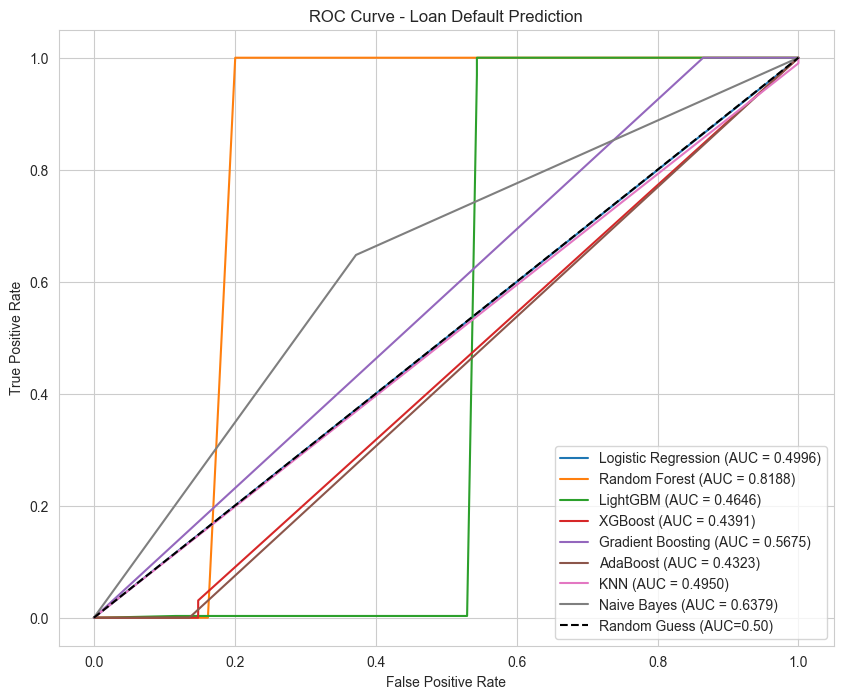

In [120]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve, auc

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from xgboost import XGBClassifier
import lightgbm as lgb


# ==============================
# STEP 1 : Align Test Columns
# ==============================

X_test_aligned = X_test.reindex(columns=X_train_resampled.columns, fill_value=0)

# Remove any NaN values
X_test_aligned = X_test_aligned.fillna(0)
X_train_resampled = X_train_resampled.fillna(0)


# ==============================
# STEP 2 : Clean Feature Names
# (Required for XGBoost)
# ==============================

X_train_resampled.columns = (
    X_train_resampled.columns
    .astype(str)
    .str.replace('[^A-Za-z0-9_]+', '_', regex=True)
)

X_test_aligned.columns = (
    X_test_aligned.columns
    .astype(str)
    .str.replace('[^A-Za-z0-9_]+', '_', regex=True)
)


# ==============================
# STEP 3 : Define Models
# ==============================

models = {

    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "Random Forest":
        RandomForestClassifier(random_state=42),

    "LightGBM":
        lgb.LGBMClassifier(random_state=42, verbosity=-1),

    "XGBoost":
        XGBClassifier(random_state=42, eval_metric='logloss'),

    "Gradient Boosting":
        GradientBoostingClassifier(random_state=42),

    "AdaBoost":
        AdaBoostClassifier(random_state=42),

    "KNN":
        KNeighborsClassifier(),

    "Naive Bayes":
        GaussianNB()
}


# ==============================
# STEP 4 : Train & Evaluate
# ==============================

for name, model in models.items():

    print(f"\n=============================")
    print(f"MODEL : {name}")
    print(f"=============================")

    # Train
    model.fit(X_train_resampled, y_train_resampled)

    # Predict
    y_pred = model.predict(X_test_aligned)

    # Accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print("Accuracy:", round(accuracy,4))

    # ROC-AUC
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_aligned)[:,1]
        roc_auc = roc_auc_score(y_test, y_prob)
        print("ROC-AUC:", round(roc_auc,4))

    print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, zero_division=0))


# ==============================
# STEP 5 : ROC Curve Plot
# ==============================

plt.figure(figsize=(10,8))

for name, model in models.items():

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test_aligned)[:,1]

    elif hasattr(model, "decision_function"):
        y_proba = model.decision_function(X_test_aligned)

    else:
        continue

    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.4f})")


# Random baseline
plt.plot([0,1],[0,1],'k--',label="Random Guess (AUC=0.50)")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Loan Default Prediction")
plt.legend()
plt.grid(True)
plt.show()

In [121]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Align test columns with train columns
X_test_aligned = X_test.reindex(columns=X_train_resampled.columns, fill_value=0)

# Remove any NaN values
X_train_resampled = X_train_resampled.fillna(0)
X_test_aligned = X_test_aligned.fillna(0)

# Loop through models
for name, model in models.items():

    print("\n==============================")
    print(f"MODEL: {name}")
    print("==============================")

    # Train model
    model.fit(X_train_resampled, y_train_resampled)

    # Predict
    y_pred = model.predict(X_test_aligned)

    # Accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print("Accuracy:", round(accuracy, 4))

    # ROC-AUC Score
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_aligned)[:, 1]
        roc_auc = roc_auc_score(y_test, y_prob)
        print("ROC-AUC:", round(roc_auc, 4))

    # Classification report (fixes warning)
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred, zero_division=0))


MODEL: Logistic Regression
Accuracy: 0.2463
ROC-AUC: 0.4996

Classification Report:

              precision    recall  f1-score   support

           0       0.14      0.00      0.00     22406
           1       0.25      1.00      0.40      7328

    accuracy                           0.25     29734
   macro avg       0.19      0.50      0.20     29734
weighted avg       0.17      0.25      0.10     29734


MODEL: Random Forest
Accuracy: 0.7535
ROC-AUC: 0.8188

Classification Report:

              precision    recall  f1-score   support

           0       0.75      1.00      0.86     22406
           1       0.00      0.00      0.00      7328

    accuracy                           0.75     29734
   macro avg       0.38      0.50      0.43     29734
weighted avg       0.57      0.75      0.65     29734


MODEL: LightGBM
Accuracy: 0.7535
ROC-AUC: 0.4646

Classification Report:

              precision    recall  f1-score   support

           0       0.75      1.00      0.86     22

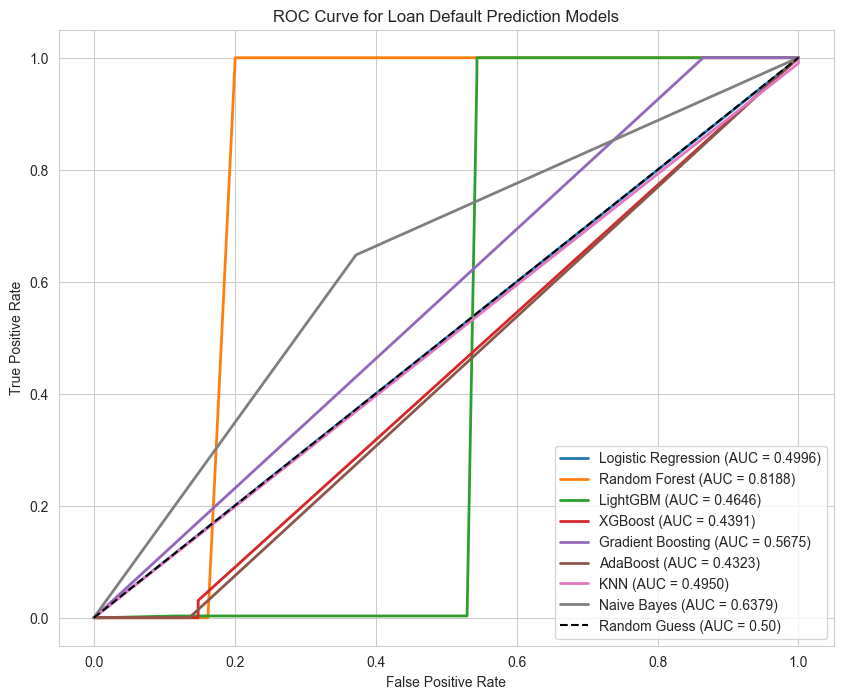

In [122]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Create figure
plt.figure(figsize=(10,8))

for name, model in models.items():

    try:
        # Get predicted probabilities
        if hasattr(model, "predict_proba"):
            y_proba = model.predict_proba(X_test_aligned)[:,1]

        elif hasattr(model, "decision_function"):
            y_proba = model.decision_function(X_test_aligned)

        else:
            print(f"{name} does not support probability prediction.")
            continue

        # Compute ROC values
        fpr, tpr, thresholds = roc_curve(y_test, y_proba)

        # Compute AUC score
        roc_auc = auc(fpr, tpr)

        # Plot curve
        plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {roc_auc:.4f})")

    except Exception as e:
        print(f"Error with {name}: {e}")

# Random baseline
plt.plot([0,1],[0,1],'k--',label="Random Guess (AUC = 0.50)")

# Labels
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Loan Default Prediction Models")

plt.legend()
plt.grid(True)
plt.show()

In [123]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import pandas as pd

# Store evaluation results
results_list = []

print("\n--- Starting Final Evaluation on the Unseen Test Data ---")

for name, model in models.items():

    print("\n===================================")
    print(f"Evaluating Model: {name}")
    print("===================================")

    # Predict on test data
    y_pred = model.predict(X_test_aligned)

    # Calculate metrics (avoid division errors)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    print(f"\nAccuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1-score  : {f1:.4f}")

    # Confusion Matrix
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    print("-" * 50)

    # Store results
    results_list.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    })

print("\n--- Final Evaluation Complete ---")

# Convert results to DataFrame
results_df = pd.DataFrame(results_list)

# Sort models by F1-score
results_df = results_df.sort_values(by="F1-score", ascending=False)

# Show results
print("\nModel Comparison Table:\n")
print(results_df)


--- Starting Final Evaluation on the Unseen Test Data ---

Evaluating Model: Logistic Regression

Accuracy  : 0.2463
Precision : 0.2463
Recall    : 0.9992
F1-score  : 0.3952

Confusion Matrix:
[[    1 22405]
 [    6  7322]]

Classification Report:
              precision    recall  f1-score   support

           0       0.14      0.00      0.00     22406
           1       0.25      1.00      0.40      7328

    accuracy                           0.25     29734
   macro avg       0.19      0.50      0.20     29734
weighted avg       0.17      0.25      0.10     29734

--------------------------------------------------

Evaluating Model: Random Forest

Accuracy  : 0.7535
Precision : 0.0000
Recall    : 0.0000
F1-score  : 0.0000

Confusion Matrix:
[[22406     0]
 [ 7328     0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.75      1.00      0.86     22406
           1       0.00      0.00      0.00      7328

    accuracy             